<a href="https://colab.research.google.com/github/Neu-Utkarsh/Practice-PyTorch/blob/main/MyTorch_00/03.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
from torch import nn
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


In [2]:
import torchvision
from torchvision import datasets
from torchvision.transforms import ToTensor


In [3]:
torchvision.__version__

'0.23.0+cpu'

In [4]:
## Using MNIST Fashion Dataset

train_data = datasets.FashionMNIST(root="data",
                                    train=True, download=True,
                                    transform=ToTensor(),
                                    target_transform=None)

test_data = datasets.FashionMNIST(root="data",
                                    train=False, download=True,
                                    transform=ToTensor(),
                                    target_transform=None)

100%|██████████| 26.4M/26.4M [00:00<00:00, 113MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 3.52MB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 61.3MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 25.6MB/s]


In [5]:
len(train_data), len(test_data)

(60000, 10000)

In [6]:
image, label = train_data[0]
image.shape, label

(torch.Size([1, 28, 28]), 9)

In [7]:
class_names = train_data.class_to_idx #.classes also for only names
class_names
class_names = train_data.classes


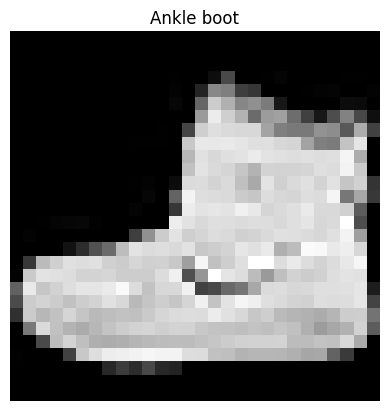

In [8]:
# First Training example
plt.imshow(image.squeeze(),cmap='gray')
plt.title(train_data.classes[label])
plt.axis('off')
plt.show()

## Using DataLoader

In [9]:
from torch.utils.data import DataLoader

train_dataloader = DataLoader(dataset=train_data,
                              batch_size= 32,
                              shuffle=True)
test_dataloader = DataLoader(dataset=test_data,
                              batch_size= 32,
                              shuffle=False)

 To make data iterable we use next(iter....

In [10]:
train_features_batch, train_labels_batch = next(iter(train_dataloader))
train_features_batch.shape, train_labels_batch.shape

(torch.Size([32, 1, 28, 28]), torch.Size([32]))

(np.float64(-0.5), np.float64(27.5), np.float64(27.5), np.float64(-0.5))

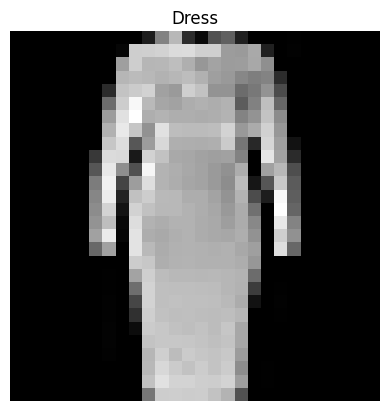

In [11]:
random_idx = torch.randint(0, len(train_features_batch), size=[1]).item()
img, label = train_features_batch[random_idx], train_labels_batch[random_idx]
plt.imshow(img.squeeze(), cmap='gray')
plt.title(class_names[label])
plt.axis(False)

## Building Models (Baseline model)

In [13]:
 class FashionMNISTModelV1(nn.Module):
  def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
    super().__init__()
    self.layer_stack = nn.Sequential(
        nn.Flatten(),
        nn.Linear(input_shape, hidden_units),
        nn.Linear(hidden_units, output_shape)
    )
  def forward(self, x):
    return self.layer_stack(x)

In [14]:
torch.manual_seed(42)

model_0 = FashionMNISTModelV1(
    input_shape=784,
    hidden_units=10,
    output_shape=len(class_names)
)

model_0

FashionMNISTModelV1(
  (layer_stack): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=10, bias=True)
    (2): Linear(in_features=10, out_features=10, bias=True)
  )
)

In [15]:
dummy_x = torch.rand(1,1,28,28)
model_0(dummy_x)

tensor([[-0.0315,  0.3171,  0.0531, -0.2525,  0.5959,  0.2112,  0.3233,  0.2694,
         -0.1004,  0.0157]], grad_fn=<AddmmBackward0>)

In [16]:
## Loss and optimizer
loss_fn = nn.CrossEntropyLoss()

optimizer = torch.optim.SGD(params=model_0.parameters(), lr=0.1)

In [17]:
import requests
from pathlib import Path

if Path("helper_functions.py").is_file():
  print("helper_functions.py already exists")

else :
  print("Downloading helper_functions.py")
  request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py")
  with open("helper_functions.py", "wb") as f:
    f.write(request.content)

In [18]:
from helper_functions import accuracy_fn

In [19]:
# Track time of your experiments

from timeit import default_timer as timer
def print_train_time(start: float, end: float, device: torch.device = None):
  total_time = end - start
  print(f"Train time on {device}: {total_time:.3f} seconds")
  return total_time

In [20]:
# Import tqdm for progress bar
from tqdm.auto import tqdm

torch.manual_seed(42)
train_time_start_on_cpu = timer()

epochs = 3

for epoch in tqdm(range(epochs)):
    print(f"Epoch: {epoch}\n-------")

    train_loss = 0

    for batch, (X, y) in enumerate(train_dataloader):
        model_0.train()

        y_pred = model_0(X)

        loss = loss_fn(y_pred, y)
        train_loss += loss # accumulatively add up the loss per epoch

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        if batch % 400 == 0:
            print(f"Looked at {batch * len(X)}/{len(train_dataloader.dataset)} samples")

    train_loss /= len(train_dataloader)

    test_loss, test_acc = 0, 0
    model_0.eval()
    with torch.inference_mode():
        for X, y in test_dataloader:
            test_pred = model_0(X)

            # 2. Calculate loss (accumulatively)
            test_loss += loss_fn(test_pred, y) # accumulatively add up the loss per epoch

            test_acc += accuracy_fn(y_true=y, y_pred=test_pred.argmax(dim=1))

        test_loss /= len(test_dataloader)

        test_acc /= len(test_dataloader)

    print(f"\nTrain loss: {train_loss:.5f} | Test loss: {test_loss:.5f}, Test acc: {test_acc:.2f}%\n")

train_time_end_on_cpu = timer()
total_train_time_model_0 = print_train_time(start=train_time_start_on_cpu,
                                           end=train_time_end_on_cpu,
                                           device=str(next(model_0.parameters()).device))

  0%|          | 0/3 [00:00<?, ?it/s]

Epoch: 0
-------
Looked at 0/60000 samples
Looked at 12800/60000 samples
Looked at 25600/60000 samples
Looked at 38400/60000 samples
Looked at 51200/60000 samples

Train loss: 0.59039 | Test loss: 0.50954, Test acc: 82.04%

Epoch: 1
-------
Looked at 0/60000 samples
Looked at 12800/60000 samples
Looked at 25600/60000 samples
Looked at 38400/60000 samples
Looked at 51200/60000 samples

Train loss: 0.47633 | Test loss: 0.47989, Test acc: 83.20%

Epoch: 2
-------
Looked at 0/60000 samples
Looked at 12800/60000 samples
Looked at 25600/60000 samples
Looked at 38400/60000 samples
Looked at 51200/60000 samples

Train loss: 0.45503 | Test loss: 0.47664, Test acc: 83.43%

Train time on cpu: 20.914 seconds


In [21]:
torch.manual_seed(42)
def eval_model(model: torch.nn.Module,
               data_loader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               accuracy_fn):
    """Returns a dictionary containing the results of model predicting on data_loader.

    Args:
        model (torch.nn.Module): A PyTorch model capable of making predictions on data_loader.
        data_loader (torch.utils.data.DataLoader): The target dataset to predict on.
        loss_fn (torch.nn.Module): The loss function of model.
        accuracy_fn: An accuracy function to compare the models predictions to the truth labels.

    Returns:
        (dict): Results of model making predictions on data_loader.
    """
    loss, acc = 0, 0
    model.eval()
    with torch.inference_mode():
        for X, y in data_loader:
            # Make predictions with the model
            y_pred = model(X)

            # Accumulate the loss and accuracy values per batch
            loss += loss_fn(y_pred, y)
            acc += accuracy_fn(y_true=y,
                                y_pred=y_pred.argmax(dim=1)) # For accuracy, need the prediction labels (logits -> pred_prob -> pred_labels)

        # Scale loss and acc to find the average loss/acc per batch
        loss /= len(data_loader)
        acc /= len(data_loader)

    return {"model_name": model.__class__.__name__, # only works when model was created with a class
            "model_loss": loss.item(),
            "model_acc": acc}

# Calculate model 0 results on test dataset
model_0_results = eval_model(model=model_0, data_loader=test_dataloader,
    loss_fn=loss_fn, accuracy_fn=accuracy_fn
)
model_0_results

{'model_name': 'FashionMNISTModelV1',
 'model_loss': 0.4766390025615692,
 'model_acc': 83.42651757188499}

In [22]:
# Model with non-linearity

class FashionMNISTModelV1(nn.Module):
  def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
    super().__init__()
    self.layer_stack = nn.Sequential(
        nn.Flatten(),
        nn.Linear(input_shape, hidden_units),
        nn.ReLU(),
        nn.Linear(hidden_units, output_shape),
        nn.ReLU()
    )
  def forward(self, x):
    return self.layer_stack(x)

In [23]:
model_1 = FashionMNISTModelV1(
    input_shape=784,
    hidden_units=10,
    output_shape=len(class_names)
)

model_1

FashionMNISTModelV1(
  (layer_stack): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=10, bias=True)
    (2): ReLU()
    (3): Linear(in_features=10, out_features=10, bias=True)
    (4): ReLU()
  )
)

In [24]:
from helper_functions import accuracy_fn

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model_1.parameters(), lr=0.1)

In [25]:
def train_step(model: torch.nn.Module,
               data_loader,
               loss_fn,optimizer, accuracy_fn):
    train_loss, train_acc = 0,0
    model.train()

    for batch, (X, y) in enumerate (data_loader) :
        y_pred = model(X)

        loss = loss_fn(y_pred, y)
        train_loss += loss
        train_acc += accuracy_fn(y_true=y, y_pred=y_pred.argmax(dim=1))

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    train_loss /= len(data_loader)
    train_acc /= len(data_loader)

    print(f"Train loss: {train_loss:.5f} | Train acc: {train_acc:.2f}%")


In [26]:
def test_step(model: torch.nn.Module,
              data_loader,
              loss_fn,
              accuracy_fn):
    test_loss, test_acc = 0,0
    model.eval()
    with torch.inference_mode():
      for X,y in data_loader:
        test_pred = model(X)
        test_loss += loss_fn(test_pred, y)
        test_acc += accuracy_fn(y_true=y, y_pred=test_pred.argmax(dim=1))

      test_loss /= len(data_loader)
      test_acc /= len(data_loader)

      print(f"Test loss: {test_loss:.5f} | Test acc: {test_acc:.2f}%")

In [27]:
torch.manual_seed(42)

train_time_start = timer()

epochs = 3
for epoch in tqdm(range(epochs)):
    print(f"Epoch: {epoch}\n-------")
    train_step(model=model_1, data_loader=train_dataloader, loss_fn=loss_fn, optimizer=optimizer, accuracy_fn=accuracy_fn)

    test_step(model=model_1, data_loader=test_dataloader, loss_fn=loss_fn, accuracy_fn=accuracy_fn)

train_time_end = timer()
total_train_time_model_1 = print_train_time(start=train_time_start,
                                           end=train_time_end,
                                           device=str(next(model_1.parameters()).device))

  0%|          | 0/3 [00:00<?, ?it/s]

Epoch: 0
-------
Train loss: 0.98248 | Train acc: 65.06%
Test loss: 0.76060 | Test acc: 72.80%
Epoch: 1
-------
Train loss: 0.70374 | Train acc: 74.43%
Test loss: 0.71959 | Test acc: 73.53%
Epoch: 2
-------
Train loss: 0.67371 | Train acc: 75.37%
Test loss: 0.69469 | Test acc: 74.71%
Train time on cpu: 21.111 seconds


In [28]:
model_1_results = eval_model(model=model_1, data_loader=test_dataloader,
    loss_fn=loss_fn, accuracy_fn=accuracy_fn
)
model_1_results

{'model_name': 'FashionMNISTModelV1',
 'model_loss': 0.6946897506713867,
 'model_acc': 74.71046325878594}

In [29]:
model_0_results

{'model_name': 'FashionMNISTModelV1',
 'model_loss': 0.4766390025615692,
 'model_acc': 83.42651757188499}

## CNNs

In [30]:
class FashionMNISTModelV2(nn.Module):
  def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
    super().__init__()
    self.conv_block_1 = nn.Sequential(
        nn.Conv2d(in_channels=input_shape,
                  out_channels=hidden_units,
                  kernel_size=3,
                  stride=1,
                  padding=1),
        nn.ReLU(),
        nn.Conv2d(in_channels=hidden_units,
                  out_channels=hidden_units,
                  kernel_size=3,
                  stride=1,
                  padding=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2)
    )
    self.conv_block_2 = nn.Sequential(
        nn.Conv2d(hidden_units, hidden_units, 3,stride=1, padding=1),
        nn.ReLU(),
        nn.Conv2d(hidden_units, hidden_units, 3, stride=1, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(2)
    )
    self.classifier = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features=hidden_units*7*7, out_features=output_shape)
    )

  def forward(self, x):
    x = self.conv_block_1(x)
    x = self.conv_block_2(x)
    return self.classifier(x)

In [31]:
model_2 = FashionMNISTModelV2(input_shape=1,
                              hidden_units=10,
                              output_shape=len(class_names))

In [32]:
loss = nn.CrossEntropyLoss()

optimizer = torch.optim.SGD(params=model_2.parameters(),
                             lr=0.1)

In [33]:
torch.manual_seed(42)

# Measure time
from timeit import default_timer as timer
train_time_start_model_2 = timer()

# Train and test model
epochs = 3
for epoch in tqdm(range(epochs)):
    print(f"Epoch: {epoch}\n---------")
    train_step(data_loader=train_dataloader,
        model=model_2,
        loss_fn=loss,
        optimizer=optimizer,
        accuracy_fn=accuracy_fn

    )
    test_step(data_loader=test_dataloader,
        model=model_2,
        loss_fn =loss,
        accuracy_fn=accuracy_fn
    )

train_time_end_model_2 = timer()
total_train_time_model_2 = print_train_time(start=train_time_start_model_2,
                                           end=train_time_end_model_2)

  0%|          | 0/3 [00:00<?, ?it/s]

Epoch: 0
---------
Train loss: 0.58554 | Train acc: 78.68%
Test loss: 0.39109 | Test acc: 86.14%
Epoch: 1
---------
Train loss: 0.35544 | Train acc: 87.16%
Test loss: 0.34115 | Test acc: 87.87%
Epoch: 2
---------
Train loss: 0.31586 | Train acc: 88.54%
Test loss: 0.32359 | Test acc: 88.35%
Train time on None: 42.807 seconds


In [34]:
model_2_results = eval_model(model=model_2, data_loader=test_dataloader,
    loss_fn=loss, accuracy_fn=accuracy_fn
)
model_2_results

{'model_name': 'FashionMNISTModelV2',
 'model_loss': 0.32358986139297485,
 'model_acc': 88.34864217252397}

In [35]:
model_0_results

{'model_name': 'FashionMNISTModelV1',
 'model_loss': 0.4766390025615692,
 'model_acc': 83.42651757188499}

## Compare results

In [36]:
results = pd.DataFrame([model_0_results,
                       model_1_results,
                       model_2_results])
results

,model_name,model_loss,model_acc
0,FashionMNISTModelV1,0.476639,83.426518
1,FashionMNISTModelV1,0.694690,74.710463
2,FashionMNISTModelV2,0.323590,88.348642


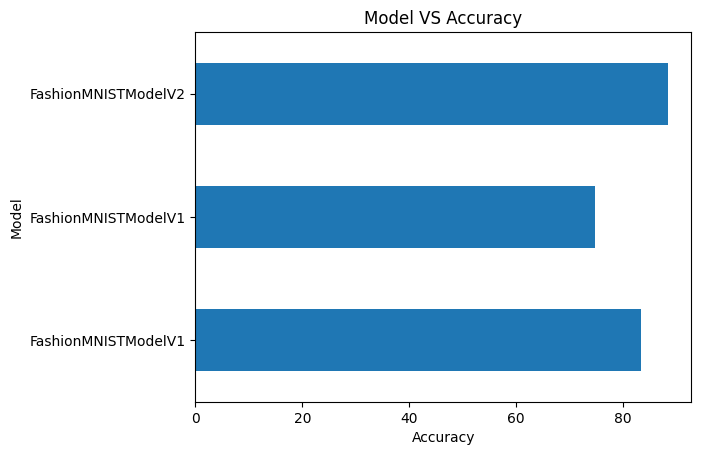

In [37]:
results.set_index('model_name')['model_acc'].plot(kind='barh')
plt.xlabel('Accuracy')
plt.ylabel('Model')
plt.title('Model VS Accuracy')
plt.show()

In [38]:
def make_predictions(model, data) :
  pred_probs = []
  model.eval()
  with torch.inference_mode() :
    for sample in data :
      sample = torch.unsqueeze(sample,dim=0)
      pred_logit = model(sample)
      pred_prob = torch.softmax(pred_logit.squeeze(), dim=0)
      pred_probs.append(pred_prob)
  pred_probs = torch.stack(pred_probs)
  return pred_probs

In [39]:
import random
# random.seed(42)

test_samples = []
test_labels = []
for sample, label in random.sample(list(test_data), k=9):
  test_samples.append(sample)
  test_labels.append(label)

test_samples[0].shape

torch.Size([1, 28, 28])

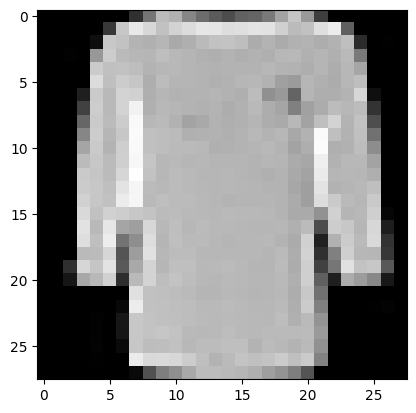

In [40]:
plt.imshow(test_samples[0].squeeze(),cmap='gray')

In [41]:
# make predictions
pred_probs = make_predictions(model=model_2, data=test_samples)
pred_probs[:2]

tensor([[3.2022e-01, 1.7590e-04, 3.1189e-01, 3.2352e-02, 5.5387e-04, 5.2588e-05,
         3.3246e-01, 1.5056e-04, 1.8790e-03, 2.7254e-04],
        [9.5034e-01, 3.0432e-05, 4.1664e-04, 6.5423e-03, 2.6523e-05, 6.6661e-07,
         4.2535e-02, 2.7635e-06, 1.1085e-04, 2.9126e-07]])

In [42]:
pred_classes = pred_probs.argmax(dim=1)
pred_classes

tensor([6, 0, 7, 7, 3, 9, 8, 2, 0])

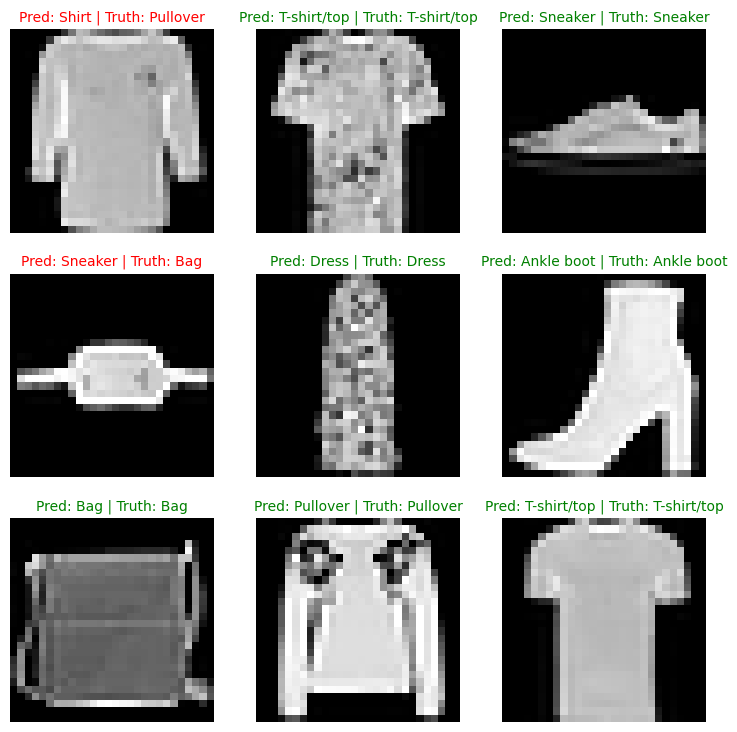

In [43]:
plt.figure(figsize=(9,9))
nrows =3
ncols =3
for i, sample in enumerate(test_samples):
  plt.subplot(nrows, ncols, i+1)
  plt.imshow(sample.squeeze(), cmap='gray')
  pred_label = class_names[pred_classes[i]]
  truth_label = class_names[test_labels[i]]
  title_text = f"Pred: {pred_label} | Truth: {truth_label}"
  if pred_label == truth_label :
    plt.title(title_text, fontsize=10, color='green')
  else :
    plt.title(title_text, fontsize=10, color='red')
  plt.axis(False)
plt.show()

In [44]:
!pip install torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 37.8 MB/s eta 0:00:00


In [48]:
!pip install mlxtend


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 35.3 MB/s eta 0:00:00


In [49]:
import mlxtend
mlxtend.__version__

'0.23.4'

In [54]:
y_preds = []
model_2.eval()
with torch.inference_mode():
  for X,y in tqdm(test_dataloader,desc= "Making predictions..."):
    y_logit = model_2(X)
    y_pred = torch.softmax(y_logit.squeeze(),dim=0).argmax(dim=1)
    y_preds.append(y_pred)

# print(y_preds)
y_pred_tensor = torch.cat(y_preds)
y_pred_tensor



Making predictions...:   0%|          | 0/313 [00:00<?, ?it/s]

tensor([9, 2, 1,  ..., 8, 1, 0])

In [55]:
len(y_pred_tensor)

10000

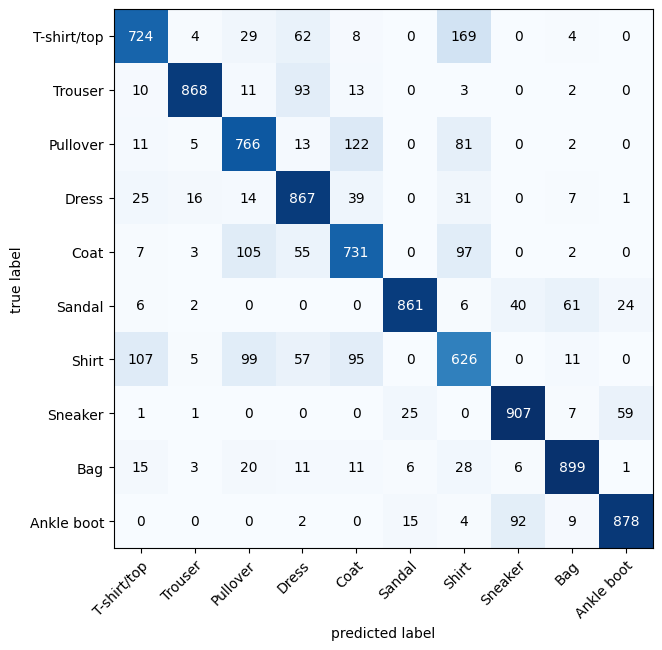

In [53]:
from torchmetrics import ConfusionMatrix
from mlxtend.plotting import plot_confusion_matrix

# 2. Setup confusion matrix instance and compare predictions to targets
confmat = ConfusionMatrix(num_classes=len(class_names), task='multiclass')
confmat_tensor = confmat(preds=y_pred_tensor,
                         target=test_data.targets)

# 3. Plot the confusion matrix
fig, ax = plot_confusion_matrix(
    conf_mat=confmat_tensor.numpy(), # matplotlib likes working with NumPy
    class_names=class_names, # turn the row and column labels into class names
    figsize=(10, 7)
);

### Saving and Loading

In [57]:
from pathlib import Path

MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True,
                 exist_ok=True
)

MODEL_NAME = "CNN.pth"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

print(f"Saving model to: {MODEL_SAVE_PATH}")
torch.save(obj=model_2.state_dict(),
           f=MODEL_SAVE_PATH)

Saving model to: models/CNN.pth


In [64]:
# model_2.state_dict()

In [65]:

loaded_model_2 = FashionMNISTModelV2(input_shape=1,
                                    hidden_units=10,
                                    output_shape=10)

loaded_model_2.load_state_dict(torch.load(f=MODEL_SAVE_PATH))


<All keys matched successfully>

In [66]:

torch.manual_seed(42)

loaded_model_2_results = eval_model(
    model=loaded_model_2,
    data_loader=test_dataloader,
    loss_fn=loss_fn,
    accuracy_fn=accuracy_fn
)

loaded_model_2_results

{'model_name': 'FashionMNISTModelV2',
 'model_loss': 0.32358986139297485,
 'model_acc': 88.34864217252397}

In [67]:
model_2_results

{'model_name': 'FashionMNISTModelV2',
 'model_loss': 0.32358986139297485,
 'model_acc': 88.34864217252397}

In [68]:
# Check to see if results are close to each other (if they are very far away, there may be an error)
torch.isclose(torch.tensor(model_2_results["model_loss"]),
              torch.tensor(loaded_model_2_results["model_loss"]),
              atol=1e-08, # absolute tolerance
              rtol=0.0001) # relative tolerance

tensor(True)